In [93]:
# Import python libraries
import pandas as pd 
import  numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

# Scikit-Learn: train-test split, preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [65]:
df = pd.read_csv("car_sales_data.csv")

In [66]:
df.columns

Index(['Manufacturer', 'Model', 'Engine size', 'Fuel type',
       'Year of manufacture', 'Mileage', 'Price'],
      dtype='object')

In [67]:
# To make a copy of the dataframe
car_data = df.copy()

In [68]:
# To view the first 10 data we have
car_data.head(10)

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
5,Ford,Focus,1.4,Petrol,2018,33603,29204
6,Ford,Mondeo,1.8,Diesel,2010,86686,14350
7,Toyota,Prius,1.4,Hybrid,2015,30663,30297
8,VW,Polo,1.2,Petrol,2012,73470,9977
9,Ford,Focus,2.0,Diesel,1992,262514,1049


#### Info & Description

In [69]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB


In [70]:
car_data.describe(include="all")

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
count,50000,50000,50000.000000,50000,50000.000000,50000.000000,50000.000000
unique,5,15,NaN,3,NaN,NaN,NaN
top,Ford,Mondeo,NaN,Petrol,NaN,NaN,NaN
freq,14959,5058,NaN,25488,NaN,NaN,NaN
mean,NaN,NaN,1.773058,NaN,2004.209440,112497.320700,13828.903160
std,NaN,NaN,0.734108,NaN,9.645965,71632.515602,16416.681336
min,NaN,NaN,1.000000,NaN,1984.000000,630.000000,76.000000
25%,NaN,NaN,1.400000,NaN,1996.000000,54352.250000,3060.750000
50%,NaN,NaN,1.600000,NaN,2004.000000,100987.500000,7971.500000
75%,NaN,NaN,2.000000,NaN,2012.000000,158601.000000,19026.500000


In [71]:
# Check for missing values in each column
car_data.isna().sum()

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

In [72]:
car_data["Fuel type"].unique()

array(['Petrol', 'Diesel', 'Hybrid'], dtype=object)

### Exploratory Data Analysis

<Axes: xlabel='Engine size', ylabel='Count'>

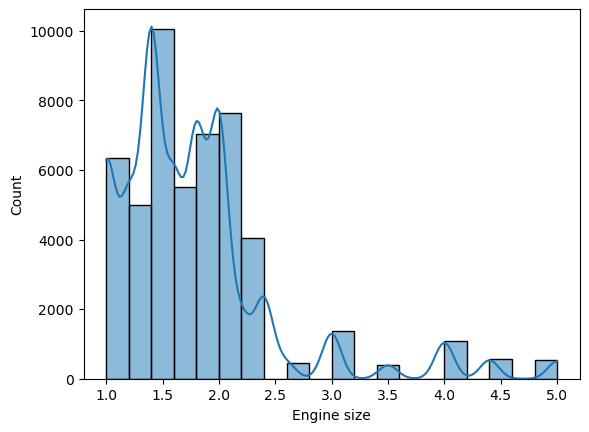

In [73]:
# To make a histogram for the car sales
sns.histplot(car_data["Engine size"], bins = 20, kde = True)

In [74]:
# Define feature groups and target
target_col = "Price"

numeric_features = ["Engine size", "Year of manufacture", "Mileage"]
categorical_features = ["Manufacturer", "Model", "Fuel type"]

# Equate them into X & Y
x = car_data[numeric_features + categorical_features]
y = car_data[target_col]

In [75]:
# Train-test split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42)

print("Number of training samples:", len(x_train))
print("Number of testing samples:", len(x_test))

Number of training samples: 40000
Number of testing samples: 10000


## Supervised Learning - Single-Feature Regression Model

In [86]:
def regression_metrics(y_true, y_pred, model_name = None):
    mae =mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    if model_name is not None:
        print(f"=== {model_name} ===")
        print(f"Mean Absolute Error (MAE): {mae:,.2f}")
        print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
        print(f"R² score: {r2:.4f}")
        print()
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [91]:
single_feature_results = []

for feature in numeric_features:
    x = car_data[[feature]].to_numpy() # converts it to 2D array
    y = car_data[target_col].to_numpy()

    # To split between training and testing datasets
    X_train, X_test, Y_train_sf, Y_test_sf = train_test_split(
        X,
        Y,
        test_size = 0.2,
        random_state = 42
    )

In [88]:
# To standardise the input feature 
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [89]:
# Create an instance of the model.
car_linear = LinearRegression()
car_linear.fit(X_train_scaled, Y_train_sf)

LinearRegression()

In [90]:
y_pred_lin =car_linear.predict(X_test_scaled)
metrics_lin = regression_metrics(
    Y_test_sf,
    y_pred_lin,
    model_name=f"{feature} - Linear Regression"
)
single_feature_results.append(metrics_lin)

=== Mileage - Linear Regression ===
Mean Absolute Error (MAE): 7,964.78
Root Mean Squared Error (RMSE): 12,746.32
R² score: 0.4013



In [95]:
# Polynomial Regression Model 

# assigning polynomial degree a variable 
poly_degree = 2

poly = PolynomialFeatures(degree=poly_degree, include_bias = False)
x_train_poly = poly.fit_transform(X_train_scaled)
x_test_poly = poly.transform(X_test_scaled)

In [97]:
poly_model = LinearRegression()
poly_model.fit(x_train_poly, Y_train_sf)

LinearRegression()

In [103]:
y_pred_poly = poly_model.predict(x_test_poly)
metrics_poly = regression_metrics(
        Y_test_sf,
        y_pred_poly,
        model_name=f"{feature} – Polynomial Regression (deg {poly_degree})"
    )
single_feature_results.append(metrics_poly)

=== Mileage – Polynomial Regression (deg 2) ===
Mean Absolute Error (MAE): 6,409.91
Root Mean Squared Error (RMSE): 11,385.09
R² score: 0.5224



In [104]:
# To summarise the single-feature models
single_feature_df = pd.DataFrame(single_feature_results)
single_feature_df.sort_values(by="RMSE")

,Model,MAE,RMSE,R2
0,Mileage – Polynomial Regression (deg 2),6409.911605,11385.091662,0.522358
1,Mileage – Polynomial Regression (deg 2),6409.911605,11385.091662,0.522358


In [46]:
gradient = car_linear.coef_[0]
intercept = car_linear.intercept_

print("gradient: ", gradient)
print("intercept: ", intercept)

gradient:  -10374.07544570737
intercept:  13854.6287


#### Regression 

#### Supervised Learning